# <img src="https://img.icons8.com/fluency/96/000000/particles.png" style="height:50px;display:inline"> Deep Latent Particles & Latent Particle World Models - Tutorial
---

<a href="">Tal Daniel</a>



<center>
    <a href="https://colab.research.google.com/github/taldatech/lpwm/blob/main/dlpv3_lpwm_walkthrough_tutorial.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
</center>

* Paper: [**Latent Particle World Models: Self-supervised Object-centric Stochastic Dynamics Modeling**, Tal Daniel, Carl Qi, Dan Haramati, Amir Zadeh, Chuan Li, Aviv Tamar, Deepak Pathak, David Held](https://openreview.net/forum?id=lTaPtGiUUc)
* GitHub: <a href="https://github.com/taldatech/lpwm">lpwm</a>
* Wepage: <a href="https://taldatech.github.io/lpwm-web/">Latent Particle World Models</a>

<center><img src="https://github.com/taldatech/lpwm-web/blob/main/assets/sketchy_particlegrid.gif?raw=true" style="height:250px"></center>

### <img src="https://img.icons8.com/color/96/000000/loading.png" style="height:50px;display:inline"> Running Instructions
---
* This Jupyter Notebook can be opened locally with Anaconda, or online via Google Colab.
* To run online, go to https://colab.research.google.com/ and drag-and-drop the `dlpv3_lpwm_walkthrough_tutorial.ipynb` file.
    * On Colab, note the "directory" icon on the left, logs, figures and checkpoints are saved in this directory.
* To run the training on the image dataset, it is better to have a GPU. In Google Cola select `Runtime->Change runtime type->GPU`.

### <img src="https://img.icons8.com/color/96/000000/software-installer.png" style="height:50px;display:inline"> Requirements
---
* If running locally, make sure to set up the environment, preferably with <a href="https://anaconda.org/">Anaconda</a> by running `conda env create -f environment.yml` or with `pip` by running `pip install -r requirements.txt`.
* If running online on <a href="https://colab.research.google.com">Google Colab</a>, run the following cell to clone the repository.

In [ ]:
# only run this cell if running on Google Colab
!git clone https://github.com/taldatech/lpwm.git
%cd lpwm

In [ ]:
# make sure the notebook is run from the root directory of the project (i.e., not from inside the `notebooks` dir)
%cd ..

### <img src="https://img.icons8.com/bubbles/50/000000/checklist.png" style="height:50px;display:inline"> Agenda
---
* [Introduction](#-Introduction)
* [DLPv3 - Model](#-DLPv3---Model)
    * [Encoder](#Encoder)
    * [Decoder](#Decoder)
    * [DLPv3 - Hyperparameters and Example Usage](#-DLPv3---Hyperparameters-and-Example-Usage)
    * [Training Example - Random Shapes Dataset](#-Training-Example---Random-Shapes-Dataset)
    * [Visualization and Manipulation](#Visualization-and-Manipulation)
* [LPWM - Model](#-LPWM---Model)
    * [Context Module](#Context-Module)
    * [Dynamics Module and Particle Grid](#Dynamics-Module-and-Particle-Grid)
    * [LPWM - Hyperparameters and Example Usage](#-LPWM---Hyperparameters-and-Example-Usage)
* [Credits](#-Credits)

In [2]:
# imports
# torch
import torch
# utils
from utils.util_func import get_config
# models
from models import DLP
# datasets
from datasets.get_dataset import get_image_dataset
from datasets.shapes_ds import generate_shape_dataset_torch
# training
from train_dlp import train_dlp
# visualization
import matplotlib.pyplot as plt
# configs
import json

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

### <img src="https://img.icons8.com/bubbles/50/000000/mention.png" style="height:50px;display:inline"> Introduction
---
* In this tutorial, we will give a brief overview of the deep latent particles (DLP) framework, and introduce DLPv3 and its extension to world models, LPWM.
* DLP is a representation of visual data that disentangles object position from appearance.
* DLP decomposes the visual input into low-dimensional latent ``particles''. 


A foreground latent particle $$ z = [z_p, z_s, z_d, z_t, z_f] \in \mathbb{R}^{6 + d_{\text{obj}}} $$ is a disentangled latent variable composed of the following learned stochastic latent attributes:

* Position $ z_p \sim \mathcal{N}(\mu_p, \sigma_p^2) \in \mathbb{R}^2 $
* Scale $ z_s \sim \mathcal{N}(\mu_s, \sigma_s^2) \in \mathbb{R}^2 $
* Depth $ z_d \sim \mathcal{N}(\mu_d, \sigma_d^2) \in \mathbb{R} $
* Transparency $ z_t \sim \text{Beta}(a_t, b_t) \in \mathbb{R} $
* Visual features $ z_f \sim \mathcal{N}(\mu_f, \sigma_f^2) \in \mathbb{R}^{d_{\text{obj}}}$, where $m$ is the dimension of learned visual features.
* Background $z_{\text{bg}} \sim \mathcal{N}(\mu_{\text{bg}}, \sigma_{\text{bg}}^2) \in \mathbb{R}^{d_{\text{bg}}} $, always located in the center of the image and described only by $d_{\text{bg}}$ latent background visual features.

<center><img src="https://github.com/taldatech/lpwm-web/blob/main/assets/attributes.png?raw=true" style="height:250px"></center>

* DLP is trained with a variational autoencoder (VAE) objective with a special prior for particle positions based on a spatial-softmax architecture, and a modification of the evidence lower bound (ELBO) loss inspired by the Chamfer distance between particles.

### <img src="https://img.icons8.com/external-flaticons-flat-flat-icons/64/000000/external-neural-network-the-future-flaticons-flat-flat-icons.png" style="height:50px;display:inline"> DLPv3 - Model
---
* DLPv3 extends [DLP](https://taldatech.github.io/deep-latent-particles-web/) and [DLPv2](https://taldatech.github.io/ddlp-web/), where an interaction module is introduced to approximate the `depth` attribute and moduleted visual features that account for spatial interactions between particles and the background.
* The basic blocks of DLPv3 are: *prior*, *encoder*, *decoder*.

#### Prior
---
* Similarly to the original DLP, to disentangle position from appearance of the particles, we consider a conditional VAE formulation, where a prior for the keypoints is explicitly learned given an image $x$.
* To generate a set of prior keypoints, termed *keypoint proposals* we follow a patch-based approach: the input $x \in \mathbb{R}^{H \times W \times 3}$ is split into $K_p$ patches of size $D \times D$ (usually $D\in\{8, 16\}$), and for each patch, a small convolutional neural network (CNN) followed by a spatial-softmax (SSM) layer outputs a single keypoint proposal.
* In practice, as the set of proposals can grow large with the number of patches, we *learn* to filter the keypoints to produce a subset of $L$ prior keypoints, where $L$ is a hyper-parameter. In DLPv2, the top-$L$ keypoints with the smallest sum of empirically-calculated SSM variance $s=\sigma_x^2 + \sigma_y^2 +\sigma_{xy}$ are chosen.
* In **DLPv3**, we instead postpone filtering until after other particle attributes have been estimated, which yields more reliable selection.
* Intuitively, in regions where the activation is sharp, we expect the softmax to produce a distribution with a small covariance values, which may indicate a non-background area-of-interest, e.g., objects, lines or corners, making the low-covariance a suitable criterion for detection and filtering (note that the SSM operation is differentiable).
<center>
<img src="https://github.com/taldatech/lpwm-web/blob/main/assets/ssm_fig.png?raw=true" style="height:250px">
</center>

In [ ]:
# THIS CELL IS NOT MEANT TO BE RUN
def encode_prior(self, x, k=None):
    # encodes prior keypoints by patchifying the image and applying spatial-softmax
    # x: [batch_size, cdim, image_size, image_size]
    batch_size, cdim, image_size, image_size = x.shape
    x_patches = self.img_to_patches(x)  # [batch_size, cdim, num_patches, patch_size, patch_size]
    x_patches = x_patches.permute(0, 2, 1, 3, 4)  # [batch_size, num_patches, cdim, patch_size, patch_size]
    x_patches = x_patches.contiguous().view(-1, cdim, self.patcher.patch_size, self.patcher.patch_size)
    enc_out = self.enc(x_patches)  # [batch_size*num_patches, n_kp, features_dim, features_dim]
    if isinstance(enc_out, tuple):
        z = enc_out[1]
    else:
        z = enc_out
    kp_p, var_kp = self.ssm(z, probs=False, variance=True)  # [batch_size * num_patches, n_kp, 2]
    kp_p = kp_p.view(batch_size, -1, self.n_kp, 2)  # [batch_size, num_patches, n_kp, 2]
    kp_p = self.get_global_kp(kp_p)
    var_kp = var_kp.view(batch_size, kp_p.shape[1], self.n_kp, -1)  # [batch_size, num_patches, n_kp, 3]

    if k is None:
        k = self.n_kp_prior
    kp_p = kp_p.view(x.shape[0], -1, 2)  # [batch_size, n_kp_total, 2]
    var_kp = var_kp.view(x.shape[0], kp_p.shape[1], -1)  # [batch_size, n_kp_total, 3]

    return kp_p, var_kp

#### Encoder
---
* The encoding process involves 4 steps: (1) *keypoint proposals* - a patch-based network with a spatial softmax layer generates candidate particle locations; (2) *attribute encoding* - offsets, scales, depths, and transparencies are inferred for each particle; (3) *appearance encoding* - foreground particle features, and (4) *background encoding* - global background features are extracted from the keypoint-masked image.

* **Keypoint proposals**: Given an input image $x \in \mathbb{R}^{C \times H \times W}$, we divide it into $M$ non-overlapping patches of size $D \times D$ (typically $D \in \{8 ,16\}$). Each patch is processed by the *proposal encoder* $q_{\phi}(z_a|x)$, a lightweight convolutional neural network (CNN), followed by a spatial softmax (SSM) layer, which produces a single keypoint proposal $z_a$ per patch.
* **Attribute encoding**: To infer the position offset $z_o$, scale $z_s$, depth $z_d$ (in DLPv3 `depth` is inferred later, see below), and transparency $z_t$ of each particle, we extract glimpses of size $S \times S$, where $S \geq D$, centered at the keypoint proposals $z_a$ using a Spatial Transformer Network (STN). These glimpses are processed by the *attribute encoder* $q_{\phi}(z_o, z_s, z_d,z_t|x, z_a)$, implemented as a small CNN followed by a fully connected layer, which outputs the distribution parameters described above for each particle. The encoder’s weights are shared across all particles.
* **Appearance encoding**: The visual features of each particle are extracted with the *appearance encoder* $q_{\phi}(z_f|x, z_p, z_s)$. As in the attribute stage, an STN is used to obtain glimpses of size $S$, but here the transformation is conditioned on both the particle position $z_p = z_a + z_o$ and the learned scale $z_s$, rather than a fixed patch ratio. This allows the glimpse size to adapt when objects are smaller or larger than the nominal $S \times S$ region. Since all stages rely on STN, the entire pipeline remains fully differentiable. The appearance encoder has the same architecture as the attribute encoder and outputs the Gaussian distribution parameters for the particle’s visual features.
    * **Background encoder**: In addition to object particles, we allocate a background particle anchored at the image center. Its features $z_{\text{bg}}$ are inferred by a dedicated *background encoder* $q_{\phi}(z_{\text{bg}}|x, z_p)$ which operates on a masked version of the input image. Specifically, the posterior keypoints $z_p$, along with their transparencies $z_t$, are used to generate $M$ masks of size $S \times S$, each masking out the region corresponding to a particle, leaving the background regions visible for encoding.
* **DLPv3 new additions**:
    * **Depth via particle attention**: Instead of predicting the depth attribute $z_d$ during the attribute encoding stage, we introduce an attention layer applied after attribute encoding. This attention layer takes as input all particles, including the background particle, and outputs the depth values $\{z_d^m\}_{m=0}^{M-1}$. The motivation is that relative depth is inherently a global property, best estimated by jointly considering all particle positions and features rather than independently.
    * **Residual appearance encoding**: The same attention layer is also used to refine appearance features. Specifically, in the appearance encoding stage, we first compute a deterministic feature embedding $\hat{z}_f$ for each particle. The attention layer then outputs a residual $\Delta z_f$ and variance $\sigma_f^2$, such that the final appearance distribution is
    $$
    q_\phi(z_f \mid x, z_p, z_s) = \mathcal{N}\!\left(z_f \;\middle|\; \hat{z}_f + \Delta z_f,\; \sigma_f^2\right).
    $$
    This residual modeling improves performance by allowing the network to adjust features based on contextual information from all particles.


<center><img src="https://github.com/taldatech/lpwm-web/blob/main/assets/encoder.png?raw=true" style="height:350px"></center>

In [ ]:
# THIS CELL IS NOT MEANT TO BE RUN
def encode_all(self, x, deterministic=False, warmup=False):
    """
    encoding steps:
    1. encode bg: x -> bg_enc -> [bs * T, projection_dim]
    2. encode patches: x -> patch_enc -> [bs * T, n_patches, projection_dim ]
    3. encode particles: [patches, bg, particle_tokens, bg_token, ctx_token] -> pte -> [bs, T, n_particles + 2, dim]
    """
    # make sure x is [bs, T, ch, h, w]
    if len(x.shape) == 4:
        # that means x: [bs, ch, h, w]
        x = x.unsqueeze(1)  # -> [bs, T=1, ch, h, w]
    bs, timestep_horizon, ch, h, w = x.shape
    # x = x.view(bs * timestep_horizon, *x.shape[2:])  # [bs * T, ch, h, w]
    # encode particles
    particle_dict = self.particle_enc(x, deterministic, warmup)
    # unpack
    kp_p = particle_dict['kp_p']
    var_kp = particle_dict['var_kp']
    patch_id_embed = particle_dict['patch_id_embed']
    z_base = particle_dict['z_base']
    z = particle_dict['z']
    mu_offset = particle_dict['mu_offset']
    logvar_offset = particle_dict['logvar_offset']
    z_offset = particle_dict['z_offset']
    mu_tot = particle_dict['mu_tot']
    z_base_var = particle_dict['z_base_var']
    mu_scale = particle_dict['mu_scale']
    logvar_scale = particle_dict['logvar_scale']
    z_scale = particle_dict['z_scale']
    mu_depth = particle_dict['mu_depth']
    logvar_depth = particle_dict['logvar_depth']
    z_depth = particle_dict['z_depth']
    obj_on_a = particle_dict['obj_on_a']
    obj_on_b = particle_dict['obj_on_b']
    mu_obj_on = particle_dict['mu_obj_on']
    z_obj_on = particle_dict['z_obj_on']
    mu_features = particle_dict['mu_features']
    logvar_features = particle_dict['logvar_features']
    z_features = particle_dict['z_features']
    cropped_objects = particle_dict['cropped_objects']

    z_score = particle_dict['z_score']
    mu_score = particle_dict['mu_score']
    logvar_score = particle_dict['logvar_score']

    # encode bg
    # x = x.view(bs * timestep_horizon, *x.shape[2:])  # [bs * T, ch, h, w]
    x = x.view(-1, *x.shape[2:])  # [bs * T, ch, h, w]
    z_v = z.view(-1, *z.shape[2:])
    if self.n_kp_dec != self.n_kp_enc:
        # variance filtering
        total_var = z_base_var.view(-1, *z_base_var.shape[2:]).sum(-1)
        n_filter = self.n_kp_dec if not warmup else min(self.n_kp_dec, int(self.warmup_n_kp_ratio * self.n_kp_enc))
        _, embed_ind = torch.topk(total_var, k=n_filter, dim=-1, largest=False)
        # make selection
        batch_ind = torch.arange(z_v.shape[0], device=z_v.device)[:, None]
        z_v = z_v[batch_ind, embed_ind]  # [bs * T, n_kp_enc, 2]

    if self.interaction_obj_on:
        z_obj_on_v = torch.ones(-1, z_v.shape[1], device=x.device, dtype=torch.float)
    else:
        z_obj_on_v = z_obj_on.view(-1, *z_obj_on.shape[2:]).squeeze(-1)
        if self.n_kp_dec != self.n_kp_enc:
            z_obj_on_v = z_obj_on_v[batch_ind, embed_ind]  # [bs * T, n_kp_enc, 1]

    if self.mask_bg_in_enc:
        bg_enc_mask = self.get_bg_mask_from_particle_glimpses(z_v, z_obj_on_v, mask_size=x.shape[-1])
        bg_dict = self.bg_encoder(x, bg_enc_mask, deterministic, timestep_horizon)
    else:
        bg_enc_mask = None
        bg_dict = self.bg_encoder(x, None, deterministic, timestep_horizon)  # unmasked bg
    mu_bg_features = bg_dict['mu_bg']
    mu_bg_features = mu_bg_features.view(bs, -1, mu_bg_features.shape[-1])
    logvar_bg_features = bg_dict['logvar_bg']
    if logvar_bg_features is not None:
        logvar_bg_features = logvar_bg_features.view(bs, -1, logvar_bg_features.shape[-1])
    z_bg_features = bg_dict['z_bg']
    z_bg_features = z_bg_features.view(bs, -1, z_bg_features.shape[-1])

    if self.use_particle_inter_enc:
        z_in_inter = z_base + z_offset  # so we can detach z_base (ssm) if more stable
        inter_dict = self.particle_inter_enc(x, z_in_inter, z_scale, z_obj_on, z_depth, z_features, z_bg_features,
                                             z_base_var, z_score, patch_id_embed,
                                             deterministic=deterministic, warmup=warmup)
        if self.interaction_features:
            mu_features = inter_dict['mu_features']
            logvar_features = inter_dict['logvar_features']
            z_features = inter_dict['z_features']

            if inter_dict.get('mu_bg_features') is not None:
                mu_bg_features = inter_dict['mu_bg_features']
                logvar_bg_features = inter_dict['logvar_bg_features']
                z_bg_features = inter_dict['z_bg_features']

        if self.interaction_obj_on:
            obj_on_a = inter_dict['obj_on_a']
            obj_on_b = inter_dict['obj_on_b']
            mu_obj_on = inter_dict['mu_obj_on']
            z_obj_on = inter_dict['z_obj_on']
        if self.interaction_depth:
            mu_depth = inter_dict['mu_depth']
            logvar_depth = inter_dict['logvar_depth']
            z_depth = inter_dict['z_depth']

    encode_dict = {'mu_anchor': z_base, 'logvar_anchor': torch.zeros_like(z_base), 'z_base': z_base, 'z': z,
                   'mu_offset': mu_offset, 'logvar_offset': logvar_offset, 'z_offset': z_offset, 'mu_tot': mu_tot,
                   'mu_features': mu_features, 'logvar_features': logvar_features, 'z_features': z_features,
                   'mu_bg_features': mu_bg_features, 'logvar_bg_features': logvar_bg_features,
                   'z_bg_features': z_bg_features,
                   'cropped_objects': cropped_objects.detach(), 'patch_id_embed': patch_id_embed,
                   'obj_on_a': obj_on_a, 'obj_on_b': obj_on_b, 'obj_on': z_obj_on, 'mu_obj_on': mu_obj_on,
                   'z_base_var': z_base_var,
                   'mu_depth': mu_depth, 'logvar_depth': logvar_depth, 'z_depth': z_depth,
                   'mu_scale': mu_scale, 'logvar_scale': logvar_scale, 'z_scale': z_scale,
                   'kp_p': kp_p, 'var_kp': var_kp, 'bg_enc_mask': bg_enc_mask,
                   'mu_score': mu_score, 'logvar_score': logvar_score, 'z_score': z_score,
                   }
    return encode_dict

#### Decoder
---
* Each particle is decoded into a localized appearance patch, positioned and scaled according to its spatial attributes, while transparency and depth resolve visibility and occlusions.  This compositional design parallels classical graphics pipelines, local rendering, spatial transformation, and alpha compositing, but is learned end-to-end from data, enabling the model to reconstruct complex scenes in a structured and interpretable manner.
* The decoder is composed of a *particle decoder* and a *background decoder*.
* **Particle decoder**: Each particle is decoded independently into an RGBA (RGB + Alpha) glimpse $\tilde{x}^p_i \in \mathbb{R}^{S \times S \times 4}$, representing the reconstructed appearance of particle $i$. The particle decoder consists of a fully connected layer followed by a small upsampling CNN that maps the latent feature vector $z_f^{(i)}$ into this glimpse. The alpha channel encodes a soft segmentation mask for the particle. The depth $z_d$ and transparency $z_t$ attributes modulate this mask, determining both the effective visibility and the compositing order of the particle. The spatial attributes $(z_p, z_s)$ specify the particle's position and scale, and are applied to the decoded glimpse using a Spatial Transformer Network (STN) to place it into the full-resolution canvas $\hat{x}_{\text{fg}}$.
* **Background decoder**: The background is decoded from $z_{\text{bg}}$ using a standard VAE-style network: a fully connected layer followed by an upsampling CNN produces $\hat{x}_{\text{bg}}$, and the final reconstructed image is produced according to
$$
    \hat{x} = \alpha \odot \hat{x}_{\text{fg}} + (1-\alpha) \odot \hat{x}_{\text{bg}},
$$
where $\alpha$ is the effective mask obtained from the compositing process.

<center><img src="https://github.com/taldatech/lpwm-web/blob/main/assets/decoder.png?raw=true" style="height:350px"></center>

In [ ]:
# THIS CELL IS NOT MEANT TO BE RUN
# We show important steps in building the reconstructed image

# object latents -> RGBA patches -> translate them to their original position on the canvas
def get_objects_alpha_rgb(self, z_kp, z_features, z_scale=None, translation=None, noisy=False):
    # decode the latent particles into RGBA glimpses and place them on the canvas
    dec_objects = self.object_dec(z_features)  # [bs * n_kp, 4, patch_size, patch_size]
    dec_objects = dec_objects.view(-1, self.n_kp_enc,
                                   *dec_objects.shape[1:])  # [bs, n_kp, 4, patch_size, patch_size]
    # translate patches - place the decoded glimpses on the canvas
    dec_objects_trans = self.translate_patches(z_kp, dec_objects, z_scale, translation)
    dec_objects_trans = dec_objects_trans.clamp(0, 1)  # STN can change values to be < 0
    # dec_objects_trans: [bs, n_kp, 3, im_size, im_size]
    # multiply by alpha channel
    a_obj, rgb_obj = torch.split(dec_objects_trans, [1, 3], dim=2)
    return dec_objects, a_obj, rgb_obj


# factorize the depth
def get_objects_alpha_rgb_with_depth(self, a_obj, rgb_obj, obj_on, z_depth, eps=1e-5):
    # stitching the glimpses by factoring the alpha maps and the particle's inferred depth
    # obj_on: [bs, n_kp, 1]
    # z_depth: [bs, n_kp, 1]
    # turn off inactive particles
    a_obj = obj_on[:, :, None, None, None] * a_obj  # [bs, n_kp, 1, im_size, im_size]
    rgba_obj = a_obj * rgb_obj
    # importance map
    importance_map = a_obj * torch.sigmoid(-z_depth[:, :, :, None, None])
    # normalize
    importance_map = importance_map / (torch.sum(importance_map, dim=1, keepdim=True) + eps)
    # this imitates softmax to move objects on the depth axis
    dec_objects_trans = (rgba_obj * importance_map).sum(dim=1)
    alpha_mask = 1.0 - (importance_map * a_obj).sum(dim=1)
    a_obj = importance_map * a_obj
    return a_obj, alpha_mask, dec_objects_trans


def decode_all(self, z, z_features, z_bg, obj_on, z_depth, z_scale):
    # a wrapper function to convert latent particles to an RGB image
    # foreground
    fg_dict = self.fg_module.decode_all(z, z_features, obj_on, z_depth=z_depth, z_scale=z_scale)
    dec_objects = fg_dict['dec_objects']
    dec_objects_trans = fg_dict['dec_objects_trans']
    alpha_masks = fg_dict['alpha_masks']
    bg_mask = fg_dict['bg_mask']
    # background
    bg = self.bg_module.decode_all(z_bg)
    # stitch the final image
    rec = bg_mask * bg + dec_objects_trans
    decoder_out = {'rec': rec, 'dec_objects': dec_objects, 'dec_objects_trans': dec_objects_trans,
                   'bg': bg, 'alpha_masks': alpha_masks}
    return decoder_out

### <img src="https://img.icons8.com/external-bearicons-gradient-bearicons/64/external-Example-miscellany-texts-and-badges-bearicons-gradient-bearicons.png" style="height:50px;display:inline"> DLPv3 - Hyperparameters and Example Usage
---
* We will now create an instance of DLPv3 and look at its functions outputs.
* More details are available in `/docs/example_usage.py`.

In [3]:
# example hyper-parameters
batch_size = 4
beta_kl = 0.02
beta_rec = 1.0
beta_obj = 0.02
kl_balance = 0.01  # balance between spatial attributes (x, y, scale, depth) and visual features
n_kp_enc = 42
n_kp_prior = 64
patch_size = 8  # patch size for the prior to generate prior proposals
anchor_s = 0.25  # effective patch size for the posterior: anchor_s * image_size
image_size = 64
ch = 3
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
timestep_horizon = 1
deterministic = False
warmup = False
attn_norm_type = 'rms'

learned_feature_dim = 4  # visual features
learned_bg_feature_dim = 5  # visual features
obj_res_from_fc = 4  # 8
obj_ch_mult_prior = (1, 2)  # (1, 2)
obj_ch_mult = (1, 2, 2)  # (1, 2)
obj_base_ch = 32
obj_final_cnn_ch = 32
bg_res_from_fc = 8
bg_ch_mult = (1, 1, 2, 4)
# bg_ch_mult = (1, 1, 2)
bg_base_ch = 32
bg_final_cnn_ch = 32
num_res_blocks = 1
use_resblock = True

model = DLP(cdim=ch,  # number of input image channels
            image_size=image_size,
            normalize_rgb=False,  # normalize to [-1, 1] or keep [0, 1]
            n_kp_per_patch=1,
            patch_size=patch_size,
            anchor_s=anchor_s,
            n_kp_enc=n_kp_enc,
            n_kp_prior=n_kp_prior,
            pad_mode='zeros',
            features_dist='gauss',
            learned_feature_dim=learned_feature_dim,
            learned_bg_feature_dim=learned_bg_feature_dim,
            n_fg_categories=8,
            n_fg_classes=4,
            n_bg_categories=4,
            n_bg_classes=4,
            scale_std=0.3,
            offset_std=0.2,
            obj_on_alpha=0.01,
            obj_on_beta=0.01,
            obj_on_min=1e-4,
            obj_on_max=100,
            obj_res_from_fc=obj_res_from_fc,
            obj_ch_mult_prior=obj_ch_mult_prior,
            obj_ch_mult=obj_ch_mult,
            obj_base_ch=obj_base_ch,
            obj_final_cnn_ch=obj_final_cnn_ch,
            bg_res_from_fc=bg_res_from_fc,
            bg_ch_mult=bg_ch_mult,
            bg_base_ch=bg_base_ch,
            bg_final_cnn_ch=bg_final_cnn_ch,
            use_resblock=use_resblock,
            num_res_blocks=num_res_blocks,
            cnn_mid_blocks=False,
            mlp_hidden_dim=256,
            attn_norm_type=attn_norm_type,
            pint_enc_layers=1,  # pint = particle interaction transformer
            pint_enc_heads=1,
            embed_init_std=0.2,
            particle_positional_embed=True,  # add positional embeddings for particles in transformers
            use_z_orig=True,  # for each particle, cat the patch center coordinates it originated from
            particle_score=False,  # use the particle score as feature (i.e., the kp x-y sum of variances)
            filtering_heuristic='none',  # how to filter prior keypoints, 'none' will keep all prior kp
            # dynamics hyperparameters
            timestep_horizon=timestep_horizon,
            ).to(device)
print(f'model.info():')
print(model.info())

model.info():
╔════════════════════════════════╗
║     ██████╗ ██╗     ██████╗    ║
║     ██╔══██╗██║     ██╔══██╗   ║
║     ██║  ██║██║     ██████╔╝   ║
║     ██║  ██║██║     ██╔═══╝    ║
║     ██████╔╝███████╗██║        ║
║     ╚═════╝ ╚══════╝╚═╝        ║
║          ██╗   ██╗██████╗      ║
║          ██║   ██║╚════██╗     ║
║          ██║   ██║ █████╔╝     ║
║          ╚██╗ ██╔╝ ╚═══██╗     ║
║           ╚████╔╝ ██████╔╝     ║
║            ╚═══╝  ╚═════╝      ║
╚════════════════════════════════╝

Basic Configuration

Prior Keypoint Filtering                      | 64 -> 64
Filtering Heuristic                           | none
Prior Patch Size                              | 8
Posterior Particles (Encoder)                 | 42
Posterior Particles (Decoder)                 | 42
Filter Particles in Decoder                   | False
Include Origin Patch Center                   | False
Posterior Object Patch Size                   | 16
Attention Layer Normalization                 | rms
N

In [6]:
x_ts = (timestep_horizon + 1) if timestep_horizon > 1 else 1
x = torch.rand(batch_size, x_ts, ch, image_size, image_size, device=device)

model_output = model(x, deterministic, warmup, with_loss=True, beta_kl=beta_kl,
                     beta_rec=beta_rec, kl_balance=kl_balance,
                     recon_loss_type="mse", beta_obj=beta_obj)
# let's see what's inside
print(f'model(x) output:')
for k in model_output.keys():
    if model_output[k] is not None and not isinstance(model_output[k], dict):
        print(f'{k}: {model_output[k].shape}')

model(x) output:
kp_p: torch.Size([4, 64, 2])
rec: torch.Size([4, 3, 64, 64])
rec_rgb: torch.Size([4, 3, 64, 64])
mu_anchor: torch.Size([4, 1, 42, 2])
logvar_anchor: torch.Size([4, 1, 42, 2])
z_base_var: torch.Size([4, 1, 42, 5])
z_base: torch.Size([4, 1, 42, 2])
z: torch.Size([4, 1, 42, 2])
mu_offset: torch.Size([4, 1, 42, 2])
logvar_offset: torch.Size([4, 1, 42, 2])
z_offset: torch.Size([4, 1, 42, 2])
mu_tot: torch.Size([4, 1, 42, 2])
mu_features: torch.Size([4, 1, 42, 4])
logvar_features: torch.Size([4, 1, 42, 4])
z_features: torch.Size([4, 1, 42, 4])
bg: torch.Size([4, 3, 64, 64])
bg_rgb: torch.Size([4, 3, 64, 64])
mu_bg_features: torch.Size([4, 1, 5])
logvar_bg_features: torch.Size([4, 1, 5])
z_bg_features: torch.Size([4, 1, 5])
cropped_objects_original: torch.Size([168, 3, 16, 16])
cropped_objects_original_rgb: torch.Size([168, 3, 16, 16])
obj_on_a: torch.Size([4, 1, 42, 1])
obj_on_b: torch.Size([4, 1, 42, 1])
obj_on: torch.Size([4, 1, 42, 1])
mu_obj_on: torch.Size([4, 1, 42, 1])

`kp_p`: torch.Size([4, 64, 2])  # prior proposals

`rec` : torch.Size([4, 3, 64, 64])  # full reconstructions

`rec_rgb`: torch.Size([4, 3, 64, 64])  # full reconstructions in RGB (in case imgs are normalized differently)

`mu_anchor`: torch.Size([4, 1, 42, 2])  # filtered kp proposals

`logvar_anchor`: torch.Size([4, 1, 42, 2])  # constant

`z_base_var`: torch.Size([4, 1, 42, 5])  # particle variance from SSM (first 3 dimensions) and `logvar_offset`

`z_base`: torch.Size([4, 1, 42, 2])  # =`mu_anchor`

`z`: torch.Size([4, 1, 42, 2])  # final kp

`mu_offset`: torch.Size([4, 1, 42, 2])  # kp offset

`logvar_offset`: torch.Size([4, 1, 42, 2])

`z_offset`: torch.Size([4, 1, 42, 2])

`mu_tot`: torch.Size([4, 1, 42, 2])  # final mean of the position

`mu_features`: torch.Size([4, 1, 42, 4])  # visual appearance features

`logvar_features`: torch.Size([4, 1, 42, 4])

`z_features`: torch.Size([4, 1, 42, 4])

`bg`: torch.Size([4, 3, 64, 64])  # reconstructed bg

`bg_rgb`: torch.Size([4, 3, 64, 64])  # reconstructed bg in RGB

`mu_bg_features`: torch.Size([4, 1, 5])  # bg appearance features

`logvar_bg_features`: torch.Size([4, 1, 5])

`z_bg_features`: torch.Size([4, 1, 5])

`cropped_objects_original`: torch.Size([168, 3, 16, 16])  # extracted glimpses from the original image

`cropped_objects_original_rgb`: torch.Size([168, 3, 16, 16])  # same but in RGB

`obj_on_a`: torch.Size([4, 1, 42, 1])  # transparency beta distribution "a" parameter

`obj_on_b`: torch.Size([4, 1, 42, 1])  # transparency beta distribution "b" parameter

`obj_on`: torch.Size([4, 1, 42, 1])  # transparency attribute (z_t)

`mu_obj_on`: torch.Size([4, 1, 42, 1])  # mean of z_t

`dec_objects_original`: torch.Size([4, 42, 4, 16, 16])  # decoded glimpses (rgb + alpha channel)

`dec_objects_original_rgb`: torch.Size([4, 42, 4, 16, 16])  # same but in RGB

`dec_objects`: torch.Size([4, 3, 64, 64])  # decoded foreground

`mu_depth`: torch.Size([4, 1, 42, 1])  # depth attribute

`logvar_depth`: torch.Size([4, 1, 42, 1])

`z_depth`: torch.Size([4, 1, 42, 1])

`mu_scale`: torch.Size([4, 1, 42, 2])  # scale (bounding box) attribute

`logvar_scale`: torch.Size([4, 1, 42, 2])

`z_scale`: torch.Size([4, 1, 42, 2])

`alpha_masks`: torch.Size([4, 42, 1, 64, 64])  # objects masks

`mu_score`: torch.Size([4, 1, 42, 1])  # score for each particle (based on z_base_var, it is not used)

`logvar_score`: torch.Size([4, 1, 42, 1])

`z_score`: torch.Size([4, 1, 42, 1])

In [7]:
# loss calculation
all_losses = model.calc_elbo(x, model_output, beta_kl=beta_kl,
                             beta_rec=beta_rec, kl_balance=kl_balance,
                             recon_loss_type="mse", warmup=warmup, beta_obj=beta_obj)
# let's see what's inside
print(f'model.calc_elbo(): model losses:')
for k in all_losses.keys():
    print(f'{k}: {all_losses[k]}')

model.calc_elbo(): model losses:
loss: 103.82564544677734
psnr: 10.791144371032715
kl: 233.15765380859375
kl_dyn: 0.0
loss_rec: 1024.157470703125
obj_on_l1: 21.6300048828125
loss_kl_kp: 108.02266693115234
loss_kl_feat: 586.5654296875
loss_kl_obj_on: 58.43592071533203
loss_kl_scale: 60.79736328125
loss_kl_depth: 0.03604136407375336
loss_kl_context: 0.0
loss_obj_reg: 471.78973388671875


`loss`: the complete loss (for `loss.backward()`)

`psnr`: mean PSNR

`kl`: complete kl-divergence (of all components)

`loss_rec`: reconstruction loss

`obj_on_l1`: if all particles are "on" then obj_on_l1=n_particles, effective # of visible particles

`loss_kl_kp`: kl of the position

`loss_kl_feat`: kl of the visual features

`loss_kl_obj_on`: kl of the transparency

`loss_kl_scale`: kl of the scale

`loss_kl_depth`: kl of the depth

`loss_obj_reg`: the transparency regularization loss (squared sum of all particles transparency attribute z_t)

###  <img src="https://img.icons8.com/external-icongeek26-linear-colour-icongeek26/64/000000/external-shapes-graphic-design-icongeek26-linear-colour-icongeek26.png" style="height:50px;display:inline"> Training Example - Random Shapes Dataset
---
* The model is optimized as a variational autoencoder (VAE) with objective of maximizing the evidence lower bound (ELBO): $$ \log p_\theta(x) \geq \mathbb{E}_{q(z|x)} \left[\log p_\theta(x|z)\right] - KL(q(z|x) \Vert p(z)) \doteq ELBO(x) $$
* The ELBO is decomposed to the <i>reconstruction error</i> and a <i>KL-divergence</i> regularization term.
* Let's take a look at data for the tutorial: images of random shapes of different sizes and colors.

  0%|          | 0/5 [00:00<?, ?it/s]

sample_images: <torch.utils.data.dataset.TensorDataset object at 0x7c49b99bfd00>


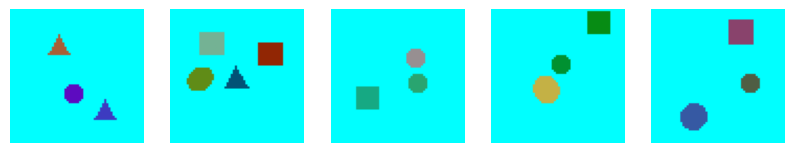

In [8]:
%matplotlib inline
sample_images = generate_shape_dataset_torch(img_size=64, num_images=5)  # [5, 3, 64, 64]
print(f'sample_images: {sample_images}')
# plot
fig = plt.figure(figsize=(10, 2))
for i in range(len(sample_images)):
    ax = fig.add_subplot(1, len(sample_images), i + 1)
    ax.imshow(sample_images[i][0].permute(1, 2, 0).data.cpu())
    ax.set_axis_off()

#### Hyper-parameters
---
DLP has some trivial hyper-parameters just like any other model (e.g., learning rate, batch size and etc...), and the rest are described below:

* `ds`: dataset name (str)
* `obj_ch_mult_prior`: channel multiplication from `base_ch` for the prior CNN (takes in patches)
* `obj_ch_mult`: channel multiplication from `base_ch` for the particle CNNs (take in glimpses)
* `bg_ch_mult`: channel multiplication from `base_ch` for the background CNN (takes in the whole image)
* `n_kp_per_patch`: number of kp to extract from each (!) patch
* `n_kp_prior`: number of kp to filter from the set of prior kp (of size n_kp x num_patches)
* `n_kp_enc`: number of posterior kp to be learned (this is the actual number of kp that will be learnt)
* `patch_size`: patch size for the prior KP proposals network (not to be confused with the glimpse size)
* `learned_feature_dim`: the latent visual features dimensions extracted from glimpses.
* `bg_learned_feature_dim`: the latent visual features dimensions extracted from the background.
* `anchor_s`: defines the glimpse size as a ratio of image_size (e.g., 0.25 for image_size=128 -> glimpse_size=32)
* `topk`: the number top-k particles with the lowest variance (highest confidence) to filter for the plots.
* `recon_loss_type`: tpe of pixel reconstruction loss ("mse", "vgg").
* `beta_rec`: coefficient for the reconstruction loss (we use 1.0).
* `beta_kl`: coefficient for the KL divergence term in the loss.
* `beta_obj`: coefficient for the transparency regularization.
* `kl_balance`: coefficient for the balance between the KL of the attributes and the KL of the visual features, `kl_loss = beta_kl * (kl_balance * chamfer_kl + kl_attributes + kl_balance * kl_features)`

In [30]:
# lets take a look at the config file and modify it for the tutorial
shapes_config = get_config('configs/shapes.json')
shapes_config['beta_kl'] = 0.1
shapes_config['beta_obj'] = 0.1
shapes_config['n_kp_enc'] = 10
shapes_config['n_kp_prior'] = 64
shapes_config['run_prefix'] = '_dlp_tut'
shapes_config['filtering_heuristic'] = 'none'
shapes_config['num_epochs'] = 50
print(shapes_config)
# save config
conf_path = f'configs/dlp_tut.json'
with open(conf_path, 'w') as outfile:
    json.dump(shapes_config, outfile, indent=2)

{'ds': 'shapes', 'root': None, 'device': 'cuda', 'batch_size': 32, 'lr': 8e-05, 'use_scheduler': False, 'scheduler_gamma': 0.99, 'adam_betas': [0.9, 0.999], 'adam_eps': 1e-06, 'weight_decay': 0.0, 'load_model': False, 'pretrained_path': None, 'start_epoch': 0, 'num_epochs': 50, 'eval_epoch_freq': 1, 'warmup_epoch': 1, 'patch_size': 8, 'n_kp_per_patch': 1, 'n_kp_enc': 10, 'n_kp_prior': 64, 'topk': 6, 'anchor_s': 0.25, 'scale_std': 0.3, 'offset_std': 0.2, 'obj_on_alpha': 0.01, 'obj_on_beta': 0.01, 'recon_loss_type': 'mse', 'normalize_rgb': False, 'beta_kl': 0.1, 'beta_rec': 1.0, 'beta_obj': 0.1, 'kl_balance': 0.01, 'image_size': 64, 'ch': 3, 'features_dist': 'gauss', 'learned_feature_dim': 8, 'learned_bg_feature_dim': 2, 'n_fg_categories': 8, 'n_fg_classes': 4, 'n_bg_categories': 4, 'n_bg_classes': 4, 'obj_res_from_fc': 4, 'obj_ch_mult_prior': [1, 2], 'obj_ch_mult': [1, 2, 4], 'obj_base_ch': 32, 'obj_final_cnn_ch': 32, 'bg_res_from_fc': 8, 'bg_ch_mult': [1, 1, 2, 2], 'bg_base_ch': 32, 'b

In [31]:
# train
%matplotlib agg
model = train_dlp(conf_path)

  0%|          | 0/40000 [00:00<?, ?it/s]

╔════════════════════════════════╗
║     ██████╗ ██╗     ██████╗    ║
║     ██╔══██╗██║     ██╔══██╗   ║
║     ██║  ██║██║     ██████╔╝   ║
║     ██║  ██║██║     ██╔═══╝    ║
║     ██████╔╝███████╗██║        ║
║     ╚═════╝ ╚══════╝╚═╝        ║
║          ██╗   ██╗██████╗      ║
║          ██║   ██║╚════██╗     ║
║          ██║   ██║ █████╔╝     ║
║          ╚██╗ ██╔╝ ╚═══██╗     ║
║           ╚████╔╝ ██████╔╝     ║
║            ╚═══╝  ╚═════╝      ║
╚════════════════════════════════╝

Basic Configuration

Prior Keypoint Filtering                      | 64 -> 64
Filtering Heuristic                           | none
Prior Patch Size                              | 8
Posterior Particles (Encoder)                 | 10
Posterior Particles (Decoder)                 | 10
Filter Particles in Decoder                   | False
Include Origin Patch Center                   | False
Posterior Object Patch Size                   | 16
Attention Layer Normalization                 | rms
Number of Input

epoch #0 (warmup): 100%|██████| 1250/1250 [02:24<00:00,  8.64it/s, a=1.17, b=0.00939, kl=63.2, loss=7, on_l1=9.83, rec=54.1, smu=0.188]



=== Epoch ===
Epoch 0

=== Loss Metrics ===
Loss: 27.755
Reconstruction: 242.275
KL: 255.734
KL-Balance: 0.010
KL KP: 39.828
KL Features: 462.867
KL Scale: 193.369
KL Depth: 8.695
KL Transparency (obj_on): 9.214

=== Attribute Statistics ===
Total Mu: min=-1.027, max=0.894
Mu Offset: min=-0.177, max=0.315
Object On: min=0.018, max=1.000
Scale: min=0.149, max=0.227
Depth: min=-0.975, max=1.746

=== Validation ===
Loss (freq: 1): 100000000.000
Best Loss: 100000000.000 @ epoch 0
Mean PSNR: 18.590
LPIPS (freq: 1): 100000000.000
Best LPIPS: 100000000.000 @ epoch 0

bb scores: max: 15.76, min: 0.22, mean: 13.87

validation step...


  0%|          | 0/2000 [00:00<?, ?it/s]

...

  0%|          | 0/2000 [00:00<?, ?it/s]

validation loss: 0.770

validation loss updated: 0.791 -> 0.770



  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:05<00:00, 12.53it/s]


validation: lpips: 0.003, psnr: 42.271, ssim: 0.997



#### Visualization and Manipulation
---
* Let's visualize some of the model's output and manipulate learned particles.

In [32]:
from utils.util_func import plot_keypoints_on_image_batch, plot_bb_on_image_batch_from_z_scale_nms, \
    plot_bb_on_image_batch_from_masks_nms

In [33]:
img_batch = torch.stack([im[0] for im in sample_images], dim=0).to(torch.device(shapes_config['device']))
print(f'img_batch: {img_batch.shape}')

img_batch: torch.Size([5, 3, 64, 64])


In [50]:
# forward
with torch.no_grad():
    model_dict = model(img_batch, deterministic=True)
# unpack
kp_p = model_dict['kp_p']
rec = model_dict['rec']
mu = model_dict['mu_tot'][:, 0]
logvar = model_dict['logvar_offset'][:, 0]
z = model_dict['z'][:, 0]
z_depth = model_dict['z_depth'][:, 0]
z_scale = model_dict['z_scale'][:, 0]
obj_on = model_dict['obj_on'][:, 0]
z_features = model_dict['z_features'][:, 0]
z_bg = model_dict['z_bg_features'][:, 0]
bg = model_dict['bg']
cropped_objects_original = model_dict['cropped_objects_original']
dec_objects_original = model_dict['dec_objects_original']
dec_objects = model_dict['dec_objects']
alpha_masks = model_dict['alpha_masks']

In [52]:
# let's plot stuff
%matplotlib inline
x = img_batch
x_prior = x
kp_range = model.kp_range
mu_plot = z.clamp(min=kp_range[0], max=kp_range[1])
max_imgs = num_images = 4
topk = 5
iou_thresh = 0.2
img_with_kp = plot_keypoints_on_image_batch(mu_plot, x, radius=3,
                                            thickness=1, max_imgs=max_imgs, kp_range=kp_range)
img_with_kp_p = plot_keypoints_on_image_batch(kp_p, x_prior, radius=3, thickness=1, max_imgs=max_imgs,
                                              kp_range=kp_range)
# top-k
with torch.no_grad():
    logvar_sum = logvar.sum(-1) * obj_on.squeeze(-1)  # [bs, n_kp]
    logvar_topk = torch.topk(logvar_sum, k=topk, dim=-1, largest=False)
    indices = logvar_topk[1]  # [batch_size, topk]
    batch_indices = torch.arange(z.shape[0]).view(-1, 1).to(z.device)
    topk_kp = z[batch_indices, indices]
    # bounding boxes
    bb_scores = -1 * logvar_sum
    hard_threshold = None

kp_batch = mu_plot
scale_batch = z_scale
img_with_masks_nms, nms_ind = plot_bb_on_image_batch_from_z_scale_nms(kp_batch, scale_batch, x,
                                                                      scores=bb_scores,
                                                                      iou_thresh=iou_thresh,
                                                                      thickness=1, max_imgs=max_imgs,
                                                                      hard_thresh=hard_threshold)
alpha_masks = torch.where(alpha_masks < 0.05, 0.0, 1.0)
img_with_masks_alpha_nms, _ = plot_bb_on_image_batch_from_masks_nms(alpha_masks, x, scores=bb_scores,
                                                                    iou_thresh=iou_thresh, thickness=1,
                                                                    max_imgs=max_imgs,
                                                                    hard_thresh=hard_threshold)

img_with_kp_topk = plot_keypoints_on_image_batch(topk_kp.clamp(min=kp_range[0], max=kp_range[1]), x,
                                                 radius=3, thickness=1, max_imgs=max_imgs,
                                                 kp_range=kp_range)

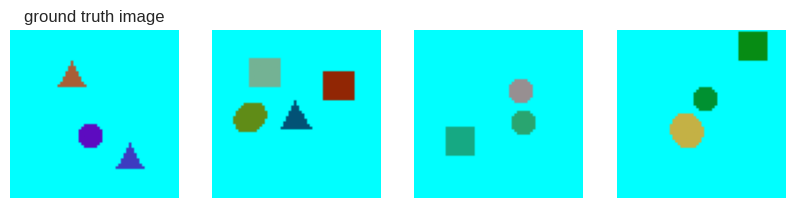

In [53]:
gt_image = img_batch.permute(0, 2, 3, 1).cpu().numpy()
fig = plt.figure(figsize=(10, 10))
for i in range(num_images):
    ax = fig.add_subplot(1, num_images, i + 1)
    ax.imshow(gt_image[i])
    ax.set_axis_off()
    if i == 0:
        ax.set_title('ground truth image')

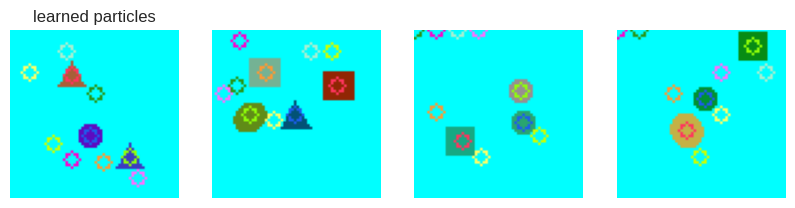

In [54]:
img_with_posterior_kp = img_with_kp.permute(0, 2, 3, 1).cpu().numpy()
fig = plt.figure(figsize=(10, 10))
for i in range(num_images):
    ax = fig.add_subplot(1, num_images, i + 1)
    ax.imshow(img_with_posterior_kp[i])
    ax.set_axis_off()
    if i == 0:
        ax.set_title('learned particles')

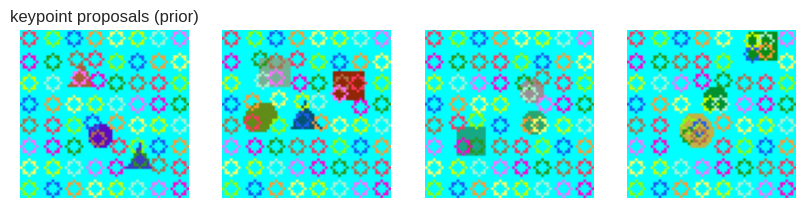

In [55]:
img_with_kp_proposals = img_with_kp_p.permute(0, 2, 3, 1).cpu().numpy()
fig = plt.figure(figsize=(10, 10))
for i in range(num_images):
    ax = fig.add_subplot(1, num_images, i + 1)
    ax.imshow(img_with_kp_proposals[i])
    ax.set_axis_off()
    if i == 0:
        ax.set_title('keypoint proposals (prior)')

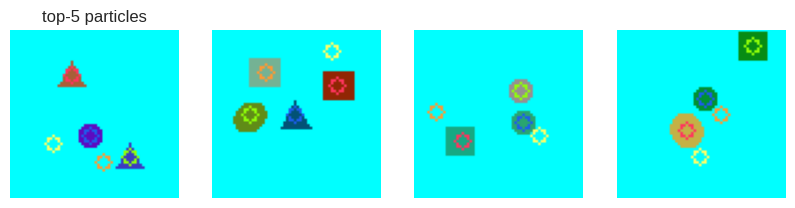

In [56]:
img_with_topk_kp = img_with_kp_topk.permute(0, 2, 3, 1).cpu().numpy()
fig = plt.figure(figsize=(10, 10))
for i in range(num_images):
    ax = fig.add_subplot(1, num_images, i + 1)
    ax.imshow(img_with_topk_kp[i])
    ax.set_axis_off()
    if i == 0:
        ax.set_title(f'top-{topk} particles')

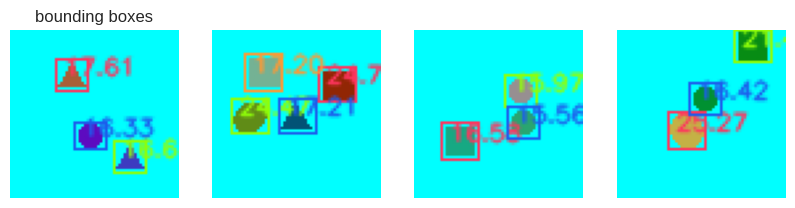

In [57]:
img_with_bb = img_with_masks_alpha_nms.permute(0, 2, 3, 1).cpu().numpy()
fig = plt.figure(figsize=(10, 10))
for i in range(num_images):
    ax = fig.add_subplot(1, num_images, i + 1)
    ax.imshow(img_with_bb[i])
    ax.set_axis_off()
    if i == 0:
        ax.set_title(f'bounding boxes')

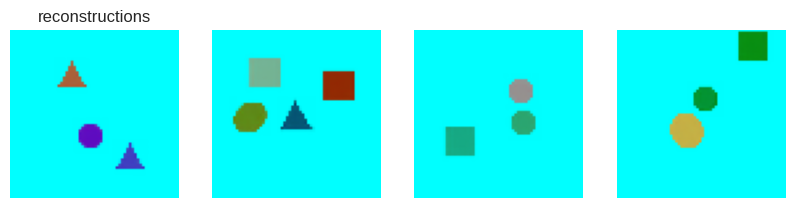

In [58]:
reconsturction = rec.permute(0, 2, 3, 1).cpu().numpy()
fig = plt.figure(figsize=(10, 10))
for i in range(num_images):
    ax = fig.add_subplot(1, num_images, i + 1)
    ax.imshow(reconsturction[i])
    ax.set_axis_off()
    if i == 0:
        ax.set_title(f'reconstructions')

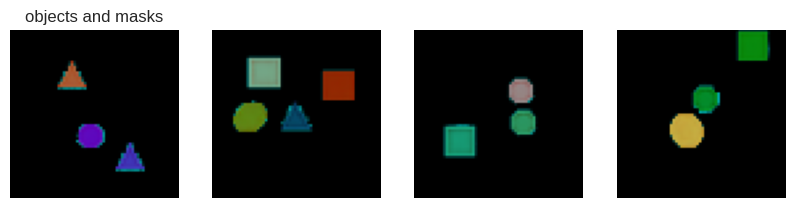

In [59]:
all_objects_with_masks = dec_objects.permute(0, 2, 3, 1).detach().cpu().numpy()
fig = plt.figure(figsize=(10, 10))
for i in range(num_images):
    ax = fig.add_subplot(1, num_images, i + 1)
    ax.imshow(all_objects_with_masks[i])
    ax.set_axis_off()
    if i == 0:
        ax.set_title(f'objects and masks')

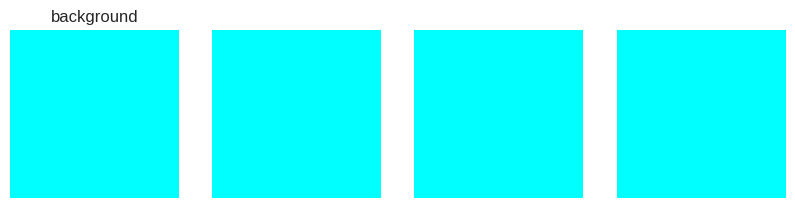

In [60]:
# background
bg_rec = bg.permute(0, 2, 3, 1).detach().cpu().numpy()
fig = plt.figure(figsize=(10, 10))
for i in range(num_images):
    ax = fig.add_subplot(1, num_images, i + 1)
    ax.imshow(bg_rec[i])
    ax.set_axis_off()
    if i == 0:
        ax.set_title(f'background')

In [63]:
# manipulation - let's move the particles a bit and see what happens
z_manip = z + 0.3
with torch.no_grad():
    decoder_dict = model.decode_all(z_manip, z_scale, z_features, obj_on, z_depth, z_bg, z_ctx=None)
rec_new = decoder_dict['rec']

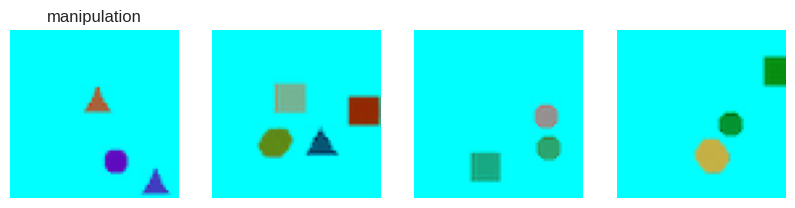

In [64]:
manip_reconstruction = rec_new.permute(0, 2, 3, 1).cpu().numpy()
fig = plt.figure(figsize=(10, 10))
for i in range(num_images):
    ax = fig.add_subplot(1, num_images, i + 1)
    ax.imshow(manip_reconstruction[i])
    ax.set_axis_off()
    if i == 0:
        ax.set_title(f'manipulation')

### <img src="https://img.icons8.com/external-flaticons-flat-flat-icons/64/000000/external-neural-network-the-future-flaticons-flat-flat-icons.png" style="height:50px;display:inline"> LPWM - Model
---
* Our goal is to design a *world model*, i.e., a dynamics model $\mathcal{F}(I_{0:T-1}, c) = \hat{I}_{T: T+\tau - 1}$ that takes in a sequence of $T$ image observations $I_{0:T-1} \in \mathbb{R}^{T \times C \times H \times W}$ (a video), where $C$ is the number of image channels (typically 3 for RGB) and $H$ and $W$ are the height and width of the images respectively, and *optionally* a sequence of conditioning signals $c$ (e.g., action sequence or language instruction), and predicts a sequence of future observations $\tau$ autoregressively $\hat{I}_{T: T+\tau - 1} \in  \mathbb{R}^{\tau \times C \times H \times W}$. We note that our world model need not be conditioned on $c$ and can be trained only with videos, i.e. $c=\emptyset$.
* Latent Particle World Models (LPWM) extends DLPv3 to world models by introducing a **context module** (latent actions) and **dynamics module**, to model the particle dynamics over time.
* In what follows, we will introduce the new components.

#### Context Module
---
* The context module is designed to address the problem of *stochastic dynamics* in actionless videos. In such videos, scene dynamics are not fully determined by the first frames (e.g., a ball starting to roll), but also by external signals such as actions (e.g., a robotic gripper moving).
* A common approach to capture such stochastic transitions is to introduce *latent actions*. Typically, a latent action $z_c$ is learned in an autoencoding scheme: an inverse model infers $z_c^t = \mathcal{K}_{\psi}^{\text{inv}}(I_{t+1}, I_t)$ from two consecutive frames, and a decoder reconstructs the future frame $\hat{I}_{t+1} = \mathcal{D}_{\theta}(I_t, z_c^t)$, with training driven by reconstruction loss. To avoid degenerate solutions where $z_c^t$ memorizes $I_{t+1}$, $z_c$ is strongly regularized, either via a vector-quantization (VQ) bottleneck or a variational bottleneck with KL-regularization to a fixed prior.
* In these designs, the latent action is *global*: a single vector encodes all changes between two frames. While this aligns with how agents are typically controlled (e.g., joint positions in robotics, discrete actions in video games), it is limited in multi-entity settings. For example, in *Mario*, enemies move independently of the player’s true action space, and in robotics, contact events can induce secondary object interactions. **A global action vector cannot naturally disentangle these local dynamics**.
* We introduce the **context module**, a novel **per-particle** mechanism for latent action modeling.
* We extend it to support external conditioning signals such as global actions (e.g., ground-truth gripper controls), language instructions, or image-based goals. Importantly, conditioning **within** the latent context module maps global scene-level signals into per-particle latent actions.
    * For instance, given a language instruction, the context module learns to translate it into per-particle latent actions that drive the dynamics towards satisfying the instruction.
* Formally, the context module takes as input a sequence of particle sets across $T+1$ frames, *optionally* conditioned on external signals $\{c_t\}_{t=0}^{T}$ (e.g., control actions, goal images, or language instructions). It outputs a sequence of per-particle latent contexts: $$ \{ [\{z_{c, \text{fg}}^{m, t}\}_{m=0}^{M-1}, z_{c, \text{bg}}^t] \}_{t=0}^{T-1}.$$ It is implemented as a **causal spatio-temporal transformer**, which jointly processes particles across space and time while ensuring autoregressive temporal dependencies.
<center><img src="https://github.com/taldatech/lpwm-web/blob/main/assets/spatiotemp_block.png?raw=true" style="height:350px"></center>

* It is composed of two complementary heads:
    * **Latent inverse dynamics** $p_{\psi}^{\text{inv}}(z_c^t \mid  z^{t+1}, z^t, \dots, z^0, c_t)$, which predicts the latent action responsible for the transition between consecutive states.
    * **Latent policy** $p_{\psi}^{\text{policy}}(z_c^t \mid z^t, \dots, z^0, c_t)$, which models the distribution of latent actions conditioned on the current state.
* The latent policy serves as a prior that regularizes the inverse dynamics via a KL-divergence penalty in the VAE objective. Specifically, the latent actions are modeled as Gaussian distributions, $z_c \sim \mathcal{N}(\mu_c, \sigma_c^2)$, parameterized by the context module.
* At **training time**, latent actions are obtained through the **inverse dynamics** head, ensuring consistency with observed transitions.
* At **inference time**, latent actions can instead be sampled directly from the latent policy prior, enabling stochastic rollouts of the world model.

<center><img src="https://github.com/taldatech/lpwm-web/blob/main/assets/ctx_hori_wp.png?raw=true" style="height:250px"></center>

#### Dynamics Module and Particle Grid
---

* The dynamics module implements the VAE's autoregressive dynamics prior
$p_{\xi}(z^t \mid z^{t-1}, \dots, z^0)$.
* It predicts the particles at the next timestep conditioned on the current particles and their corresponding latent actions provided by the context module:
$$
\mathcal{F}\!\left(\big\{[\{z_{\text{fg}}^{m, t}\}_{m=0}^{M-1},\, z_{\text{bg}}^t,\, z_c^t]\big\}_{t=0}^{T-1}\right)
= \big\{[\{\hat{z}_{\text{fg}}^{m, t}\}_{m=0}^{M-1},\, \hat{z}_{\text{bg}}^t]\big\}_{t=1}^{T}.
$$
Here $z_c^t$ denotes the latent actions at timestep $t$.
* The dynamics module $\mathcal{F}$ is implemented as a causal spatio-temporal transformer,
where particles are conditioned on their corresponding latent actions through adaptive layer normalization (AdaLN).
* $\mathcal{F}$ outputs distribution parameters that serve as the prior in the KL-divergence term between the posterior encoder and the dynamics prior.
* **Particle grid**: Differently from DDLP, LPWM does not rely on tracking a subset of particles across timesteps. Instead, it keeps the entire set of $M$ encoded particles along with their identities (i.e., the patches they originated from). This induces a *particle-grid* regime: each particle is constrained to move only within a local region around its original patch center, and when it reaches the limits of this region, its features are transferred to nearby particles.
    * This design balances between two extremes. On one side are patch-based approaches (e.g., VideoGPT), where ``particles'' are fixed at patch centers and only patch features evolve over time. On the other side are object-centric particle models (DDLP), where a subset of free-moving particles with explicit attributes (e.g., position) can traverse the entire canvas, but their identities must be tracked across time. The latter assumption may hold in controlled settings---for instance, videos with deterministic dynamics and moderate frame rates---but it fails in more general video data where actions or stochastic events occur.

<center><img src="https://github.com/taldatech/lpwm-web/blob/main/assets/particle_grid.png?raw=true" style="height:350px"></center>

In [ ]:
# THIS CELL IS NOT MEANT TO BE RUN
# context

# posterior - inverse dynamics
mu_context = enc_dict['mu_context']
logvar_context = enc_dict['logvar_context']
z_context = enc_dict['z_context']

# prior - latent policy
mu_context_dyn = enc_dict['mu_context_dyn'][:, :-1]
logvar_context_dyn = enc_dict['logvar_context_dyn'][:, :-1]
z_context_dyn = enc_dict['z_context_dyn'][:, :-1]

# forward dynamics
# [bs, T-1, n_kp, attribute/feature_dim]
z_dyn = z_base + z_offset
z_v = z_dyn[:, :-1]
z_scale_v = z_scale[:, :-1]
z_obj_on_v = z_obj_on[:, :-1]
z_depth_v = z_depth[:, :-1]
z_features_v = z_features[:, :-1]
z_bg_features_v = z_bg_features[:, :-1]

z_context_v = z_context[:, 1:]  # take the posterior latent actions

dyn_out = self.dyn_module(z_v,
                          z_scale_v,
                          z_obj_on_v,
                          z_depth_v,
                          z_features_v,
                          z_bg_features_v,
                          z_context_v)

mu_dyn = dyn_out['mu']
logvar_dyn = dyn_out['logvar']

mu_features_dyn = dyn_out['mu_features']
logvar_features_dyn = dyn_out['logvar_features']

obj_on_a_dyn = dyn_out['obj_on_a']
obj_on_b_dyn = dyn_out['obj_on_b']

mu_depth_dyn = dyn_out['mu_depth']
logvar_depth_dyn = dyn_out['logvar_depth']

mu_scale_dyn = dyn_out['mu_scale']
logvar_scale_dyn = dyn_out['logvar_scale']

mu_bg_features_dyn = dyn_out['mu_bg_features']
logvar_bg_features_dyn = dyn_out['logvar_bg_features']

The following figure summarizes the LPWM model:

<center><img src="https://github.com/taldatech/lpwm-web/blob/main/assets/arch_main_ltr.png?raw=true" style="height:350px"></center>

* Left: Input frames are encoded into particle sets by the **encoder** and decoded back to images by the **decoder**. The **context module** then processes the particles to sample latent actions, which are combined with the particles in the **dynamics module** to predict next-step particle states.
* Right: The **context module** models the per-particle latent action distribution. During training, we use the latent inverse dynamics head, while at inference, the latent policy is employed for sampling.

### <img src="https://img.icons8.com/external-bearicons-gradient-bearicons/64/external-Example-miscellany-texts-and-badges-bearicons-gradient-bearicons.png" style="height:50px;display:inline"> LPWM - Hyperparameters and Example Usage
---
* We will now create an instance of LPWM and look at its functions outputs.
* More details are available in `/docs/example_usage.py`.

In [65]:
# example hyper-parameters
batch_size = 4
beta_kl = 0.02
beta_rec = 1.0
beta_obj = 0.02
kl_balance = 0.01  # balance between spatial attributes (x, y, scale, depth) and visual features
n_kp_enc = 42
n_kp_prior = 64
patch_size = 8  # patch size for the prior to generate prior proposals
anchor_s = 0.25  # effective patch size for the posterior: anchor_s * image_size
image_size = 64
ch = 3
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
# Context and dynamics transformer configuration
pint_dyn_layers = 6  # Number of dynamics transformer layers
pint_dyn_heads = 8  # Number of dynamics transformer heads
pint_dim = 512  # Hidden dimension for PINT
pint_ctx_layers = 4  # Number of context transformer layers
pint_ctx_heads = 8  # Number of context transformer heads
beta_dyn = 0.1  # beta-kl for the dynamics loss
num_static_frames = 1  # "burn-in frames", number of initial frames with kl w.r.t. constant prior (as in DLPv2)
context_dist = 'gauss'
context_dim = 7
timestep_horizon = 10
deterministic = False
warmup = False
predict_delta = False
attn_norm_type = 'rms'

learned_feature_dim = 4  # visual features
learned_bg_feature_dim = 5  # visual features
obj_res_from_fc = 4  # 8
obj_ch_mult_prior = (1, 2)  # (1, 2)
obj_ch_mult = (1, 2, 2)  # (1, 2)
obj_base_ch = 32
obj_final_cnn_ch = 32
bg_res_from_fc = 8
bg_ch_mult = (1, 1, 2, 4)
# bg_ch_mult = (1, 1, 2)
bg_base_ch = 32
bg_final_cnn_ch = 32
num_res_blocks = 1
use_resblock = True

# actions
action_cond = False
action_d = 7
null_actions = False
action_in_ctx = True

# random actions
rand_action_cond = False
rand_action_d = 6

# language
lang_cond = False
lang_d = 128
max_lang_len = 64

# image goal condition
img_goal_cond = False

# number of views
n_im_views = 1

# episode done mask
# ep_done_mask = None
ep_dones = torch.randint(low=2, high=timestep_horizon + 2, size=(batch_size * n_im_views, 1),
                         device=device)  # [bs, 1]
ep_done_mask = torch.ones(batch_size * n_im_views, timestep_horizon + 1, dtype=torch.int, device=device)
for i in range(ep_done_mask.shape[0]):
    if ep_dones[i] < ep_done_mask.shape[1]:
        ep_done_mask[i, ep_dones[i]:] = 0.0

model = DLP(cdim=ch,  # number of input image channels
            image_size=image_size,
            normalize_rgb=False,  # normalize to [-1, 1] or keep [0, 1]
            n_views=n_im_views,
            n_kp_per_patch=1,
            patch_size=patch_size,
            anchor_s=anchor_s,
            n_kp_enc=n_kp_enc,
            n_kp_prior=n_kp_prior,
            pad_mode='zeros',
            dropout=0.1,
            features_dist='gauss',
            learned_feature_dim=learned_feature_dim,
            learned_bg_feature_dim=learned_bg_feature_dim,
            n_fg_categories=8,
            n_fg_classes=4,
            n_bg_categories=4,
            n_bg_classes=4,
            scale_std=0.3,
            offset_std=0.2,
            obj_on_alpha=0.01,
            obj_on_beta=0.01,
            obj_on_min=1e-4,
            obj_on_max=100,
            obj_res_from_fc=obj_res_from_fc,
            obj_ch_mult_prior=obj_ch_mult_prior,
            obj_ch_mult=obj_ch_mult,
            obj_base_ch=obj_base_ch,
            obj_final_cnn_ch=obj_final_cnn_ch,
            bg_res_from_fc=bg_res_from_fc,
            bg_ch_mult=bg_ch_mult,
            bg_base_ch=bg_base_ch,
            bg_final_cnn_ch=bg_final_cnn_ch,
            use_resblock=use_resblock,
            num_res_blocks=num_res_blocks,
            cnn_mid_blocks=False,
            mlp_hidden_dim=256,
            attn_norm_type=attn_norm_type,
            pint_enc_layers=1,  # pint = particle interaction transformer
            pint_enc_heads=1,
            embed_init_std=0.2,
            particle_positional_embed=True,  # add positional embeddings for particles in transformers
            use_z_orig=True,  # for each particle, cat the patch center coordinates it originated from
            particle_score=False,  # use the particle score as feature (i.e., the kp x-y sum of variances)
            filtering_heuristic='none',  # how to filter prior keypoints, 'none' will keep all prior kp
            # dynamics hyperparameters
            timestep_horizon=timestep_horizon,
            n_static_frames=num_static_frames,
            # how many initial frames should be optimized w.r.t static (constant) KL
            predict_delta=predict_delta,
            context_dim=context_dim,
            ctx_dist=context_dist,
            n_ctx_categories=8,
            n_ctx_classes=4,
            causal_ctx=True,  # model latent context with causal attention
            ctx_pool_mode='none',  # how to pool the context latents, 'none'=a context latent for each particle
            pint_dyn_layers=pint_dyn_layers,  # pint = particle interaction transformer
            pint_dyn_heads=pint_dyn_heads,
            pint_dim=pint_dim,
            pint_ctx_layers=pint_ctx_layers,
            pint_ctx_heads=pint_ctx_heads,
            action_condition=action_cond,
            action_dim=action_d,
            random_action_condition=rand_action_cond,
            random_action_dim=rand_action_d,
            null_action_embed=null_actions,
            action_in_ctx_module=action_in_ctx,
            language_condition=lang_cond,
            language_embed_dim=lang_d,
            language_max_len=max_lang_len,
            img_goal_condition=img_goal_cond
            ).to(device)
print(f'model.info():')
print(model.info())

model.info():
╔════════════════════════════════╗
║     ██████╗ ██╗     ██████╗    ║
║     ██╔══██╗██║     ██╔══██╗   ║
║     ██║  ██║██║     ██████╔╝   ║
║     ██║  ██║██║     ██╔═══╝    ║
║     ██████╔╝███████╗██║        ║
║     ╚═════╝ ╚══════╝╚═╝        ║
║          ██╗   ██╗██████╗      ║
║          ██║   ██║╚════██╗     ║
║          ██║   ██║ █████╔╝     ║
║          ╚██╗ ██╔╝ ╚═══██╗     ║
║           ╚████╔╝ ██████╔╝     ║
║            ╚═══╝  ╚═════╝      ║
╚════════════════════════════════╝

Basic Configuration

Prior Keypoint Filtering                      | 64 -> 64
Filtering Heuristic                           | none
Prior Patch Size                              | 8
Posterior Particles (Encoder)                 | 64
Posterior Particles (Decoder)                 | 42
Filter Particles in Decoder                   | True
Include Origin Patch Center                   | True
Posterior Object Patch Size                   | 16
Attention Layer Normalization                 | rms
Num

In [67]:
x_ts = (timestep_horizon + 1) if timestep_horizon > 1 else 1
x = torch.rand(batch_size * n_im_views, x_ts, ch, image_size, image_size, device=device)
if action_cond:
    actions_demo = torch.rand(batch_size * n_im_views, x_ts, action_d, device=device)
    if null_actions:
        actions_mask_demo = torch.rand(batch_size * n_im_views, x_ts, device=device) > 0.5
    else:
        actions_mask_demo = None
else:
    actions_demo = None
    actions_mask_demo = None
if lang_cond:
    lang_demo = torch.randn(batch_size, max_lang_len, lang_d, device=device)
else:
    lang_demo = None
if img_goal_cond:
    x_goal = torch.rand(batch_size * n_im_views, 1, ch, image_size, image_size, device=device)
else:
    x_goal = None
model_output = model(x, deterministic, warmup, with_loss=True, beta_kl=beta_kl,
                     beta_rec=beta_rec, kl_balance=kl_balance, beta_dyn=beta_dyn,
                     num_static=num_static_frames,
                     recon_loss_type="mse", actions=actions_demo, actions_mask=actions_mask_demo,
                     lang_embed=lang_demo, beta_obj=beta_obj, done_mask=ep_done_mask, x_goal=x_goal)
# let's see what's inside
print(f'model(x) output:')
for k in model_output.keys():
    if model_output[k] is not None and not isinstance(model_output[k], dict):
        print(f'{k}: {model_output[k].shape}')

model(x) output:
kp_p: torch.Size([44, 64, 2])
rec: torch.Size([44, 3, 64, 64])
rec_rgb: torch.Size([44, 3, 64, 64])
mu_anchor: torch.Size([4, 11, 64, 2])
logvar_anchor: torch.Size([4, 11, 64, 2])
z_base_var: torch.Size([4, 11, 64, 5])
z_base: torch.Size([4, 11, 64, 2])
z: torch.Size([4, 11, 64, 2])
mu_offset: torch.Size([4, 11, 64, 2])
logvar_offset: torch.Size([4, 11, 64, 2])
z_offset: torch.Size([4, 11, 64, 2])
mu_tot: torch.Size([4, 11, 64, 2])
mu_features: torch.Size([4, 11, 64, 4])
logvar_features: torch.Size([4, 11, 64, 4])
z_features: torch.Size([4, 11, 64, 4])
bg: torch.Size([44, 3, 64, 64])
bg_rgb: torch.Size([44, 3, 64, 64])
mu_bg_features: torch.Size([4, 11, 5])
logvar_bg_features: torch.Size([4, 11, 5])
z_bg_features: torch.Size([4, 11, 5])
mu_context: torch.Size([4, 11, 65, 7])
logvar_context: torch.Size([4, 11, 65, 7])
z_context: torch.Size([4, 11, 65, 7])
cropped_objects_original: torch.Size([1848, 3, 16, 16])
cropped_objects_original_rgb: torch.Size([1848, 3, 16, 16])


**posterior** (similar to DLPv3 above):

`kp_p`: torch.Size([44, 64, 2])

`rec`: torch.Size([44, 3, 64, 64])

`rec_rgb`: torch.Size([44, 3, 64, 64])

`mu_anchor`: torch.Size([4, 11, 64, 2])

`logvar_anchor`: torch.Size([4, 11, 64, 2])

`z_base_var`: torch.Size([4, 11, 64, 5])

`z_base`: torch.Size([4, 11, 64, 2])

`z`: torch.Size([4, 11, 64, 2])

`mu_offset`: torch.Size([4, 11, 64, 2])

`logvar_offset`: torch.Size([4, 11, 64, 2])

`z_offset`: torch.Size([4, 11, 64, 2])

`mu_tot`: torch.Size([4, 11, 64, 2])

`mu_features`: torch.Size([4, 11, 64, 4])

`logvar_features`: torch.Size([4, 11, 64, 4])

`z_features`: torch.Size([4, 11, 64, 4])

`bg`: torch.Size([44, 3, 64, 64])

`bg_rgb`: torch.Size([44, 3, 64, 64])

`mu_bg_features`: torch.Size([4, 11, 5])

`logvar_bg_features`: torch.Size([4, 11, 5])

`z_bg_features`: torch.Size([4, 11, 5])

`cropped_objects_original`: torch.Size([1848, 3, 16, 16])

`cropped_objects_original_rgb`: torch.Size([1848, 3, 16, 16])

`obj_on_a`: torch.Size([4, 11, 64, 1])

`obj_on_b`: torch.Size([4, 11, 64, 1])

`obj_on`: torch.Size([4, 11, 64, 1])

`mu_obj_on`: torch.Size([4, 11, 64, 1])

`dec_objects_original`: torch.Size([44, 42, 4, 16, 16])

`dec_objects_original_rgb`: torch.Size([44, 42, 4, 16, 16])

`dec_objects`: torch.Size([44, 3, 64, 64])

`mu_depth`: torch.Size([4, 11, 64, 1])

`logvar_depth`: torch.Size([4, 11, 64, 1])

`z_depth`: torch.Size([4, 11, 64, 1])

`mu_scale`: torch.Size([4, 11, 64, 2])

`logvar_scale`: torch.Size([4, 11, 64, 2])

`z_scale`: torch.Size([4, 11, 64, 2])

`alpha_masks`: torch.Size([44, 42, 1, 64, 64])

`mu_score`: torch.Size([4, 11, 64, 1])

`logvar_score`: torch.Size([4, 11, 64, 1])

`z_score`: torch.Size([4, 11, 64, 1])

**posterior context** (inverse dynamics module)

`mu_context`: torch.Size([4, 11, 65, 7])  # posterior latent actions

`logvar_context`: torch.Size([4, 11, 65, 7])

`z_context`: torch.Size([4, 11, 65, 7])

**prior**:

`mu_dyn`: torch.Size([4, 10, 64, 2])  # position (kp) prediction

`logvar_dyn`: torch.Size([4, 10, 64, 2])

`mu_features_dyn`: torch.Size([4, 10, 64, 4])  # visual appearance features prediction

`logvar_features_dyn`: torch.Size([4, 10, 64, 4])

`obj_on_a_dyn`: torch.Size([4, 10, 64])  # transparency prediction

`obj_on_b_dyn`: torch.Size([4, 10, 64])

`mu_depth_dyn`: torch.Size([4, 10, 64, 1])  # depth prediction

`logvar_depth_dyn`: torch.Size([4, 10, 64, 1])

`mu_scale_dyn`: torch.Size([4, 10, 64, 2])  # scale (bounding box) prediction

`logvar_scale_dyn`: torch.Size([4, 10, 64, 2])

`mu_bg_dyn`: torch.Size([4, 10, 5])  # bg features prediction

`logvar_bg_dyn`: torch.Size([4, 10, 5])

`mu_context_dyn`: torch.Size([4, 10, 65, 7])  # latent actions prediction (latent policy)

`logvar_context_dyn`: torch.Size([4, 10, 65, 7])

In [68]:
# loss calculation
all_losses = model.calc_elbo(x, model_output, beta_kl=beta_kl,
                             beta_rec=beta_rec, kl_balance=kl_balance, beta_dyn=beta_dyn,
                             num_static=num_static_frames,
                             recon_loss_type="mse", warmup=warmup, beta_obj=beta_obj, done_mask=ep_done_mask)
# let's see what's inside
print(f'model.calc_elbo(): model losses:')
for k in all_losses.keys():
    print(f'{k}: {all_losses[k]}')

model.calc_elbo(): model losses:
loss: 114.11775207519531
psnr: 10.761682510375977
kl: 56.56979751586914
kl_dyn: 958.9522705078125
loss_rec: 1031.314697265625
obj_on_l1: 32.47378921508789
loss_kl_kp: 26.424591064453125
loss_kl_feat: 140.76087951660156
loss_kl_obj_on: 13.816142082214355
loss_kl_scale: 14.872737884521484
loss_kl_depth: 0.04871632158756256
loss_kl_context: 92.00404357910156
loss_kl_score_dyn: 0.0
loss_kl_kp_dyn: 1199.4957275390625
loss_kl_feat_dyn: 8270.3037109375
loss_kl_obj_on_dyn: 30.2903995513916
loss_kl_scale_dyn: 1296.1226806640625
loss_kl_depth_dyn: 5.166628837585449
loss_obj_reg: 181.78749084472656


same as DLPV3 above, with the kl for dynamics and context as well.

In [69]:
if timestep_horizon > 1:
    num_steps = 15
    cond_steps = 5
    x = torch.rand(1 * n_im_views, num_steps + cond_steps, ch, image_size, image_size, device=device)
    if action_cond:
        actions_demo = torch.rand(1 * n_im_views, num_steps + cond_steps, action_d, device=device)
        if null_actions:
            actions_mask_demo = torch.rand(1 * n_im_views, num_steps + cond_steps, device=device) > 0.5
        else:
            actions_mask_demo = None
    else:
        actions_demo = None
        actions_mask_demo = None
    if lang_cond:
        lang_demo = torch.randn(1, max_lang_len, lang_d, device=device)
    else:
        lang_demo = None
    if img_goal_cond:
        x_goal = torch.rand(1 * n_im_views, 1, ch, image_size, image_size, device=device)
    else:
        x_goal = None
    sample_out, sample_z_out = model.sample_from_x(x, cond_steps=cond_steps, num_steps=num_steps,
                                                   deterministic=False,
                                                   return_z=True, actions=actions_demo,
                                                   actions_mask=actions_mask_demo, lang_embed=lang_demo,
                                                   x_goal=x_goal)
    # let's see what's inside
    print(f'model.sample_from_x(): model dynamics unrolling:')
    print(f'sample_out: {sample_out.shape}')
    print(f'sample_z_out:')
    for k in sample_z_out.keys():
        if sample_z_out[k] is not None:
            print(f'{k}: {sample_z_out[k].shape}')

model.sample_from_x(): model dynamics unrolling:
sample_out: torch.Size([1, 20, 3, 64, 64])
sample_z_out:
z_pos: torch.Size([1, 20, 64, 2])
z_scale: torch.Size([1, 20, 64, 2])
z_obj_on: torch.Size([1, 20, 64, 1])
z_depth: torch.Size([1, 20, 64, 1])
z_features: torch.Size([1, 20, 64, 4])
z_context: torch.Size([1, 19, 65, 7])
z_bg_features: torch.Size([1, 20, 5])
z_ids: torch.Size([1, 20, 64])
z_score: torch.Size([1, 20, 64, 1])
z_context_posterior: torch.Size([1, 4, 65, 7])
mu_context_posterior: torch.Size([1, 4, 65, 7])


`sample_out`: torch.Size([1, 20, 3, 64, 64])  #  generated frames

`sample_z_out`: # latent unrolls

`z_pos`: torch.Size([1, 20, 64, 2])

`z_scale`: torch.Size([1, 20, 64, 2])

`z_obj_on`: torch.Size([1, 20, 64, 1])

`z_depth`: torch.Size([1, 20, 64, 1])

`z_features`: torch.Size([1, 20, 64, 4])

`z_context`: torch.Size([1, 19, 65, 7])

`z_bg_features`: torch.Size([1, 20, 5])

`z_ids`: torch.Size([1, 20, 64])

`z_score`: torch.Size([1, 20, 64, 1])

`z_context_posterior`: torch.Size([1, 4, 65, 7])

`mu_context_posterior`: torch.Size([1, 4, 65, 7])

## <img src="https://img.icons8.com/dusk/64/000000/prize.png" style="height:50px;display:inline"> Credits
---
* Icons from <a href="https://icons8.com/">Icon8.com</a> - https://icons8.com